In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import sklearn
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [90]:
df = pd.read_csv('Mall_Customers.csv')

In [91]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [92]:
#Shape
shape = df.shape
print("Number of Samples:", shape[0])
print("Number of Features:", shape[1])

Number of Samples: 200
Number of Features: 5


In [93]:
# Data Wrangling
print("\nNull Values:\n", df.isnull().sum())


Null Values:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [94]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [95]:
x = df.drop(columns=['Genre','CustomerID'])

In [96]:
x

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [97]:
x = df.iloc[:,3:]
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [98]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

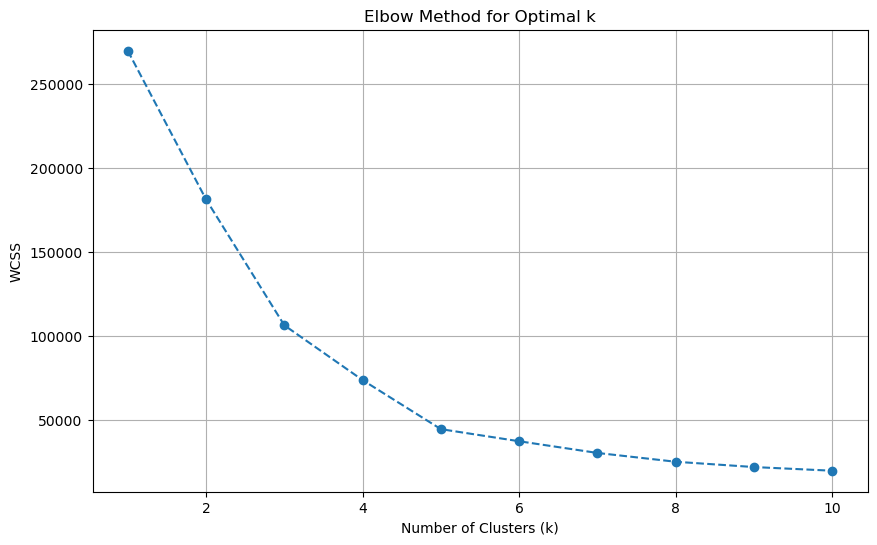

E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\A

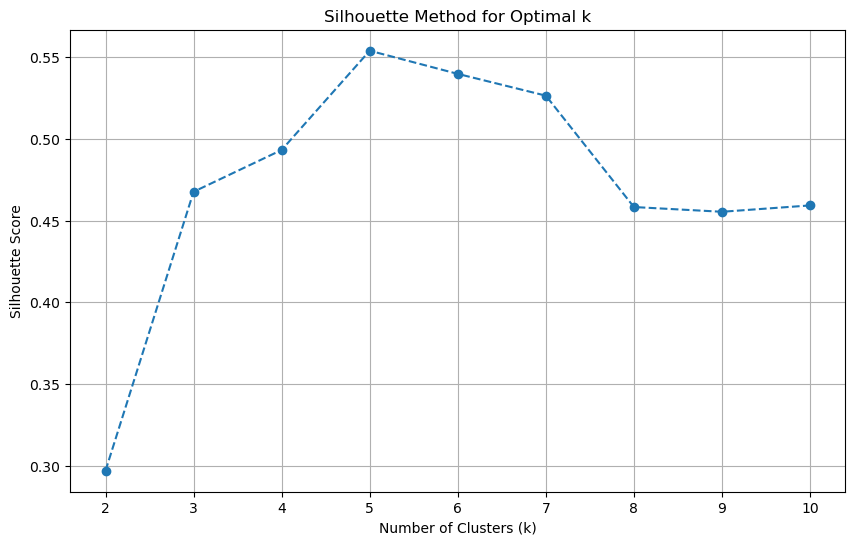

(5.0, 3, 5)

In [102]:
from sklearn.metrics import silhouette_score



# Function to calculate WCSS for the Elbow Method
def calculate_wcss(data):
    wcss = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++',n_init=10, random_state=42)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
    return wcss

# Function to calculate silhouette scores for each k value
def calculate_silhouette_scores(data):
    silhouette_scores = []
    for i in range(2, 11):  # Silhouette score is not defined for k=1
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        silhouette_scores.append(score)
    return silhouette_scores

# Calculate WCSS values for the Elbow Method
wcss = calculate_wcss(X)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Calculate silhouette scores
silhouette_scores = calculate_silhouette_scores(X)

# Plotting the Silhouette Method
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Determine the optimal k values
optimal_k_elbow = 3  # From visual inspection of the Elbow Method
optimal_k_silhouette = silhouette_scores.index(max(silhouette_scores)) + 2  # Offset by 2 because range starts at k=2

# Average the k values from both methods
average_k = ((optimal_k_elbow+1) + optimal_k_silhouette+1) / 2
average_k, optimal_k_elbow, optimal_k_silhouette


In [100]:
# So here we have decided to take 5 as our number of clusters from above analysis
km = KMeans(n_clusters=5)
labels = km.fit_predict(x)

E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [101]:
cent = km.cluster_centers_
cent

array([[86.53846154, 82.12820513],
       [55.2962963 , 49.51851852],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571]])

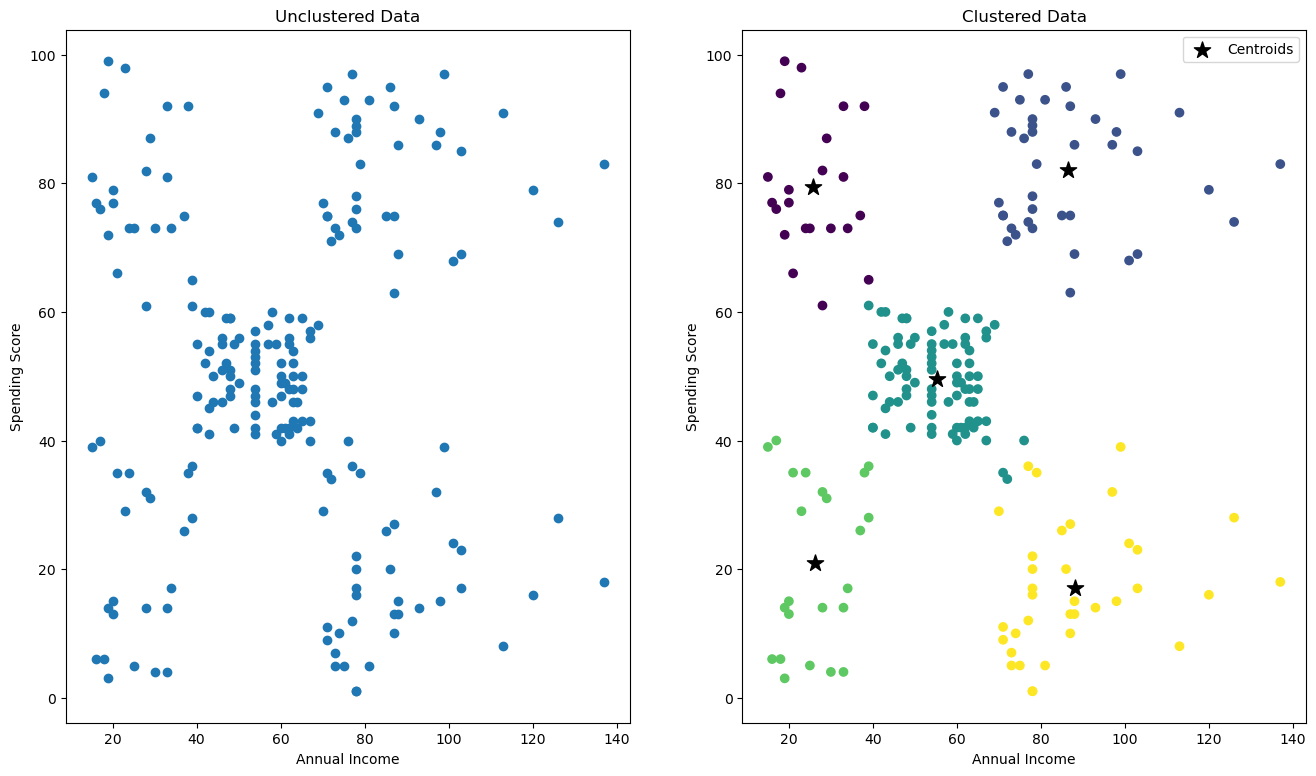

In [54]:
plt.figure(figsize=(16, 9))

# Plotting the unclustered data
plt.subplot(1, 2, 1)
plt.title('Unclustered Data')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.scatter(X[:, 0], X[:, 1])

# Plotting the clustered data with centroids marked as stars
plt.subplot(1, 2, 2)
plt.title('Clustered Data')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(cent[:, 0], cent[:, 1], s=150, color='k', marker='*', label='Centroids')
plt.legend()

plt.show()

In [83]:
from sklearn.preprocessing import StandardScaler

# Standardizing the data to bring all features to the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Recalculate WCSS and BCSS after standardization
# Fit the KMeans model with k=5 on standardized data
km_standardized = KMeans(n_clusters=5, init='k-means++', random_state=42)
labels_scaled = km_standardized.fit_predict(X_scaled)
cent_scaled = km_standardized.cluster_centers_

# Using the inertia_ attribute from the fitted KMeans model to get WCSS directly
wcss_standardized = km_standardized.inertia_

# Calculate TSS using pairwise distances on standardized data
overall_centroid_scaled = np.mean(X_scaled, axis=0)
tss_standardized = np.sum(pairwise_distances(X_scaled, overall_centroid_scaled.reshape(1, -1)) ** 2)

# Calculate BCSS using TSS and WCSS
bcss_standardized = tss_standardized - wcss_standardized

# Display results
print("Within-Cluster Sum of Squares (WCSS) after Standardization:", round(wcss_standardized, 3))
print("Between-Cluster Sum of Squares (BCSS) after Standardization:", round(bcss_standardized, 3))


E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Within-Cluster Sum of Squares (WCSS) after Standardization: 65.568
Between-Cluster Sum of Squares (BCSS) after Standardization: 334.432


In [86]:
from sklearn.model_selection import KFold

# Setting up KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)
wcss_scores = []

# Performing K-Fold Cross-Validation
for train_index, test_index in kf.split(X_scaled):
    # Splitting data into train and test sets for the current fold
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    
    # Fitting KMeans on the training set with k=5
    kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
    kmeans.fit(X_train)
    
    # Calculating WCSS on the test set
    test_labels = kmeans.predict(X_test)
    test_centroids = kmeans.cluster_centers_
    wcss = sum(np.sum((X_test[test_labels == i] - test_centroids[i]) ** 2) for i in range(5))
    wcss_scores.append(wcss)

# Calculating the mean WCSS value across all folds
mean_wcss = np.mean(wcss_scores)
mean_wcss


E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
E:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\A

14.097118325207996

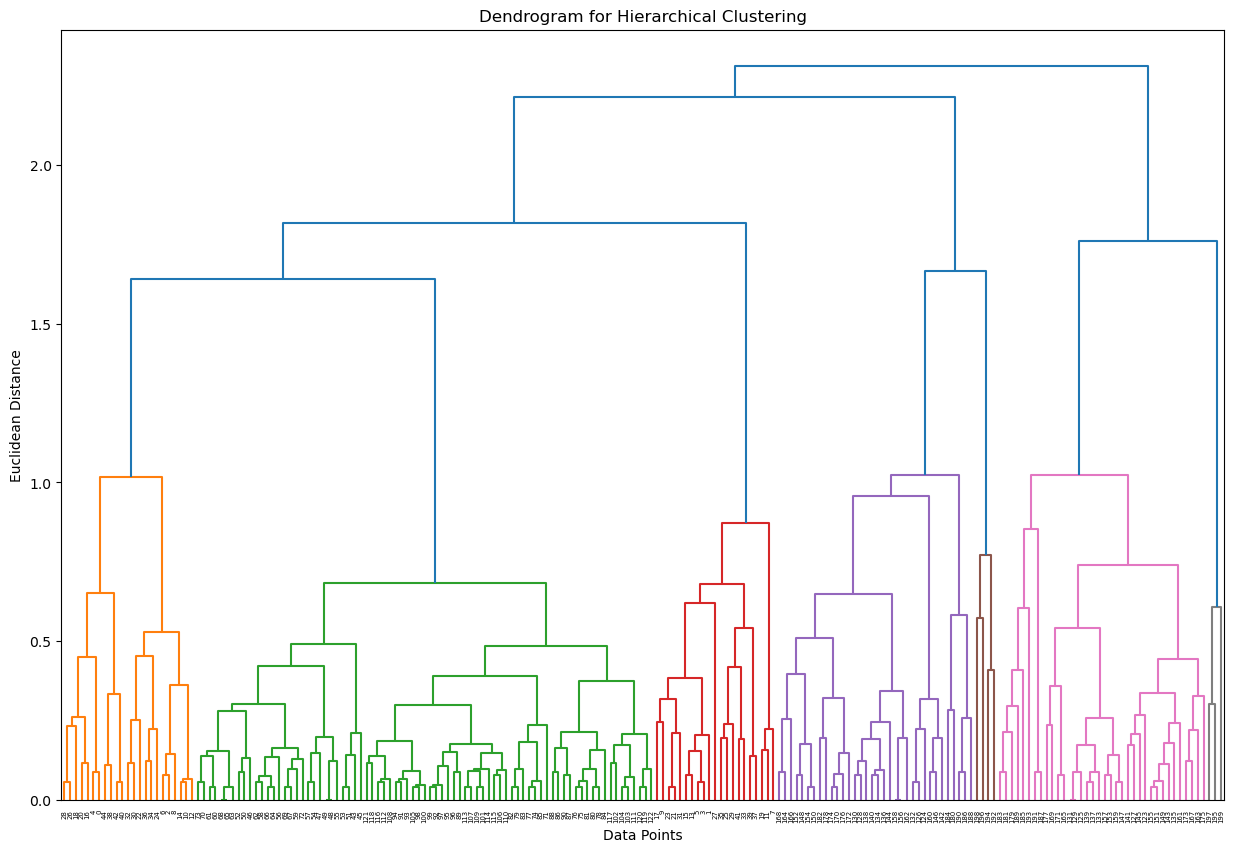

E:\Anaconda\Lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


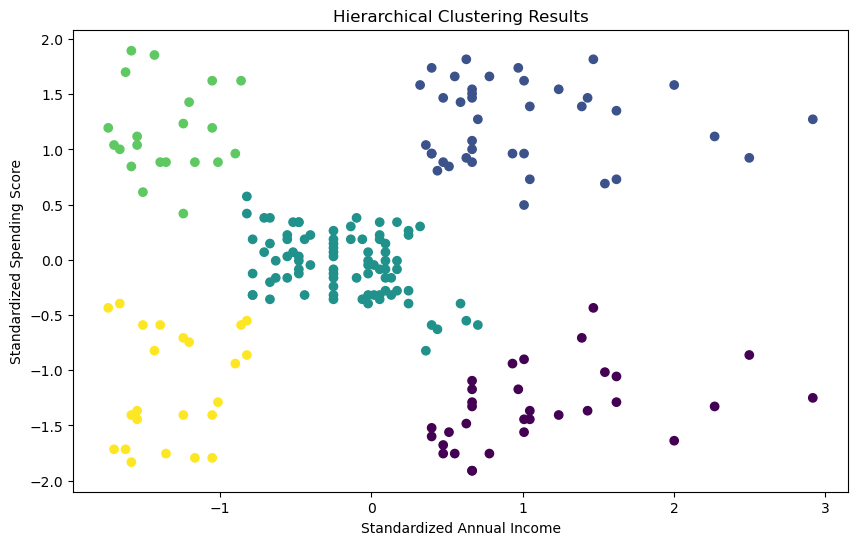

In [109]:
# Re-attempting to plot the hierarchical clustering results and dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Perform hierarchical clustering using the linkage method for dendrogram visualization
linked = linkage(X_scaled, method='average')

# Plotting the dendrogram to visualize the hierarchical clustering process
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

# Perform Agglomerative Clustering with the optimal number of clusters inferred from the dendrogram
hierarchical_clustering = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
labels_hc = hierarchical_clustering.fit_predict(X_scaled)

# Plot the hierarchical clustering results
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_hc, cmap='viridis')
plt.title('Hierarchical Clustering Results')
plt.xlabel('Standardized Annual Income')
plt.ylabel('Standardized Spending Score')
plt.show()


In [107]:
linked = linkage(X_scaled, method='average')

linked

array([[6.50000000e+01, 6.80000000e+01, 0.00000000e+00, 2.00000000e+00],
       [4.80000000e+01, 4.90000000e+01, 0.00000000e+00, 2.00000000e+00],
       [1.56000000e+02, 1.58000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.29000000e+02, 1.31000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.70000000e+02, 1.74000000e+02, 3.81694292e-02, 2.00000000e+00],
       [6.30000000e+01, 2.00000000e+02, 3.81694292e-02, 3.00000000e+00],
       [5.10000000e+01, 5.30000000e+01, 3.81694292e-02, 2.00000000e+00],
       [9.20000000e+01, 9.90000000e+01, 3.81694292e-02, 2.00000000e+00],
       [1.01000000e+02, 1.09000000e+02, 3.81694292e-02, 2.00000000e+00],
       [9.80000000e+01, 1.05000000e+02, 3.81694292e-02, 2.00000000e+00],
       [1.07000000e+02, 1.13000000e+02, 3.81694292e-02, 2.00000000e+00],
       [2.10000000e+01, 2.30000000e+01, 3.81694292e-02, 2.00000000e+00],
       [1.50000000e+02, 1.54000000e+02, 3.88215607e-02, 2.00000000e+00],
       [1.51000000e+02, 1.55000000e+02, 3.88215607e